<a href="https://colab.research.google.com/github/jpauloluzsf/luzPy/blob/main/Data_Processing/processing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

---
# **PROCESSAMENTO DE DADOS GEOELÉTRICOS - CAMINHAMENTO ELÉTRICO**
---

> Esta rotina requer recursos computacionais mínimos e pode ser executado rapidamente em segundo plano enquanto outros processos do computador estão em execução.

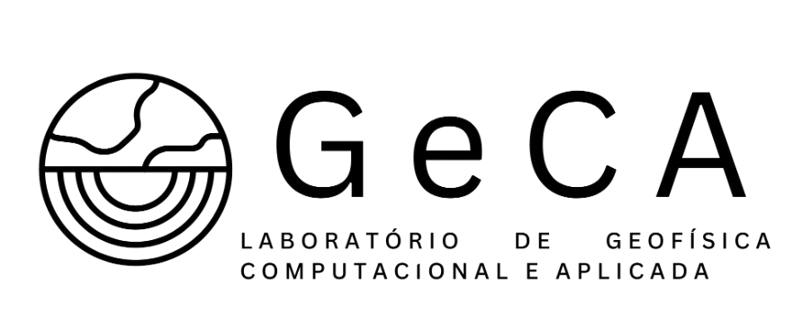

>O módulo/programa a seguir, assim como todos os demais desenvolvidos nesta biblioteca, apresenta-se como uma alternativa confiável e open-source para o processamento e análise de dados eletrorresistivos, oferecendo baixo custo computacional e eliminando a necessidade de softwares pagos. Toda a estrutura foi pensada para garantir transparência e reprodutibilidade, mantendo consistência metodológica entre os diferentes modelos e ferramentas disponibilizados.

</br>

Essa rotina baseia-se na biblioteca **SimPEG – Simulation and Parameter Estimation in Geophysics**, neste trabalho utilizamos o módulo [simpeg.electromagnetics.static.resistivity](xref:simpeg#simpeg.electromagnetics.static.resistivity).

O programa realiza o processamento e a visualização de dados de eletrorresistividade adquiridos em campo. O código organiza os dados de maneira estruturada para posterior inversão em diferentes plataformas, como **SimPEG**, **Res2DInv®** ou **ZondRes2D©**.

</br>  

**Objetivos:**  

- Compreender como definir linhas de eletrorresistividade;  
- Importar dados de campo e realizar manipulação dos mesmos;  
- Entender como definir as propriedades elétricas do meio, seja em termos de **condutividade** ou **resistividade**;  
- Incluir a **topografia da superfície** aos dados adquiridos e aos resultados posteriores;  
- Processar os dados de campo e organizá-los em diversos tipos de arquivo para posterior inversão;  
- Visualizar os dados processados em formato de **pseudoseção**.

</br>  


> Esta rotina e o material foram desenvolvidos por **João Paulo Luz Ferreira**, como aluno do **Laboratório de Geofísica Computacional e Aplicada (GeCA)**, sob orientação da professora **Flora F. Solon**.  

> A rotina foi criada para uso interno da Empresa Júnior de Geofísica da UFF – **Horizonte Soluções Geofísicas Jr.** e para estudantes em Geociências interessados em aprender e aplicar na prática conceitos teóricos de eletrorresistividade com o auxílio da biblioteca **SimPEG**.




In [ ]:
pip install -qq simpeg==0.24.0

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 508.0/508.0 kB 11.6 MB/s eta 0:00:00
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.3/1.3 MB 51.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.7/211.7 kB 17.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 172.5/172.5 kB 13.4 MB/s eta 0:00:00



## Importando Módulos

Aqui, importamos toda a funcionalidade necessária para executar o programa. Toda a funcionalidade específica para 'Dc Resistivity' é importada do módulo [simpeg.electromagnetics.static.resistivity](xref:simpeg#simpeg.electromagnetics.static.resistivity). Também importamos algumas funções utilitárias úteis do módulo [simpeg.utils](xref:simpeg#simpeg.utils).  



In [ ]:
from google.colab import drive
drive.mount('/content/drive')

from simpeg.electromagnetics.static import resistivity as dc
from simpeg.utils import model_builder
from simpeg.utils.io_utils.io_utils_electromagnetics import write_dcip2d_ubc, read_dcip2d_ubc
from simpeg import maps, data
from simpeg.electromagnetics.static.utils.static_utils import (generate_dcip_sources_line,pseudo_locations,plot_pseudosection,apparent_resistivity_from_voltage,)
from discretize import TreeMesh
from discretize.utils import active_from_xyz
import os
import numpy as np
from scipy.interpolate import interp1d
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LogNorm
from matplotlib.ticker import MultipleLocator

Mounted at /content/drive


## Definindo Parâmetros

Nesta seção, definimos os **parâmetros principais** utilizados pelo notebook para organizar e processar os dados de eletrorresistividade.  

Os parâmetros configuram aspectos essenciais do processamento, incluindo:  

- **Uso da topografia**: permite escolher se a simulação ou o processamento deve considerar a topografia real do terreno ou uma superfície plana.  
- **Formatos de saída**: define em quais formatos os dados processados serão salvos (SimPEG, Res2DInv®, ZondRes2D).  
- **Caminhos dos arquivos**: especifica os diretórios e nomes dos arquivos de entrada (dados de campo e topografia) e saída (arquivo processado).  
- **Configurações da linha de aquisição**: comprimento total da linha, espaçamento entre eletrodos e nível de inversão, parâmetros que influenciam diretamente na leitura, organização e posterior análise dos dados.  

> Configurar esses parâmetros corretamente é essencial para garantir que o processamento seja realizado de forma eficiente, que os dados adquiridos sejam interpretados de maneira consistente e que os arquivos finais possam ser utilizados para inversão e visualização em diferentes softwares.


In [ ]:
######################################## Arquivos de entrada #######################################

# Topografia?
realTopography = True


#topoPath = '.txt'
#dataPath = '.txt'

topoPath = '/content/drive/My Drive/IC/data/topo/EL4.txt'
dataPath = '/content/drive/My Drive/IC/data/base/LINHA_4_corrigida_certo.txt'

# Formato:
normalTxt = True
gtestTxt = False

######################################## Arquivo de saída ##########################################

outputDataPath = '/content/drive/My Drive/IC/data/out'
fileName = 'linha4_res2.dat'
fullPath = os.path.join(outputDataPath, fileName)

# Formato:
outSimpeg = False
outRes2d = True
outZond = False

lineLength = 300
eSpace = 10
invLevel = 5

## Definindo a Topografia

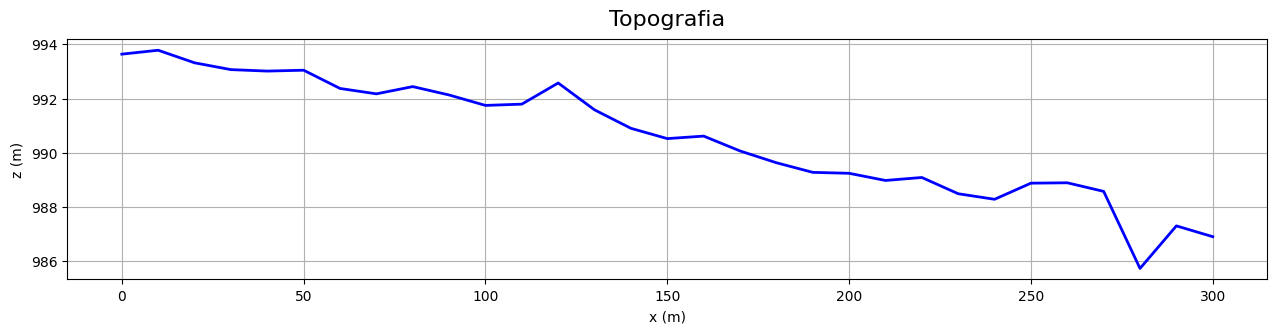

In [ ]:
# Usando topografia adquirida em campo
if realTopography:

    topo = np.loadtxt(topoPath)
    x_topo = topo[:, 0]
    z_topo = topo[:, 1]
    topo_2d = np.c_[x_topo, z_topo]

    #Plot
    fig = plt.figure(figsize=(15, 3))
    ax = fig.add_axes([0.1, 0.1, 0.8, 0.8])
    ax.plot(x_topo, z_topo, color="b", linewidth=2)
    ax.set_xlabel("x (m)", labelpad=5)
    ax.set_ylabel("z (m)", labelpad=5)
    ax.grid(True)
    ax.set_title("Topografia", fontsize=16, pad=10)
    plt.show()

# Topografia plana
else:
    x_topo = np.arange(0, lineLength + eSpace, eSpace)
    z_topo = np.zeros_like(x_topo)
    topo_2d = np.c_[x_topo, z_topo]

## Definindo o Levantamento (Survey)

Levantamentos de DC (e IP) dentro do SimPEG requerem que o usuário crie e conecte três tipos de objetos:

- [receivers](xref:simpeg#simpeg.electromagnetics.static.resistivity.receivers.BaseRx): define a localização dos eletrodos de potencial (ou MN) e o tipo de dado; por exemplo, 'volt' para tensão normalizada (V/A), 'apparent_resistivity' para resistividade aparente ($\Omega m$) ou 'apparent_chargeability' para carga aparente (adimensional). *Observação: apenas as localizações dos eletrodos M são necessárias para definir receptores tipo pólo*.  
- [sources](xref:simpeg#simpeg.electromagnetics.static.resistivity.sources.BaseSrc): define a localização dos eletrodos de corrente (ou AB) e seus receptores associados. *Observação: apenas as localizações dos eletrodos A são necessárias para definir fontes tipo pólo*.  
- [survey](xref:simpeg#simpeg.electromagnetics.static.resistivity.Survey): objeto que armazena e organiza todas as fontes e receptores.

Número de pontos totais : 130
Pontos presentes no "afunilamento" da aquisição: 10
Ponto a partir do qual o trapézio passa a afunilar: 120


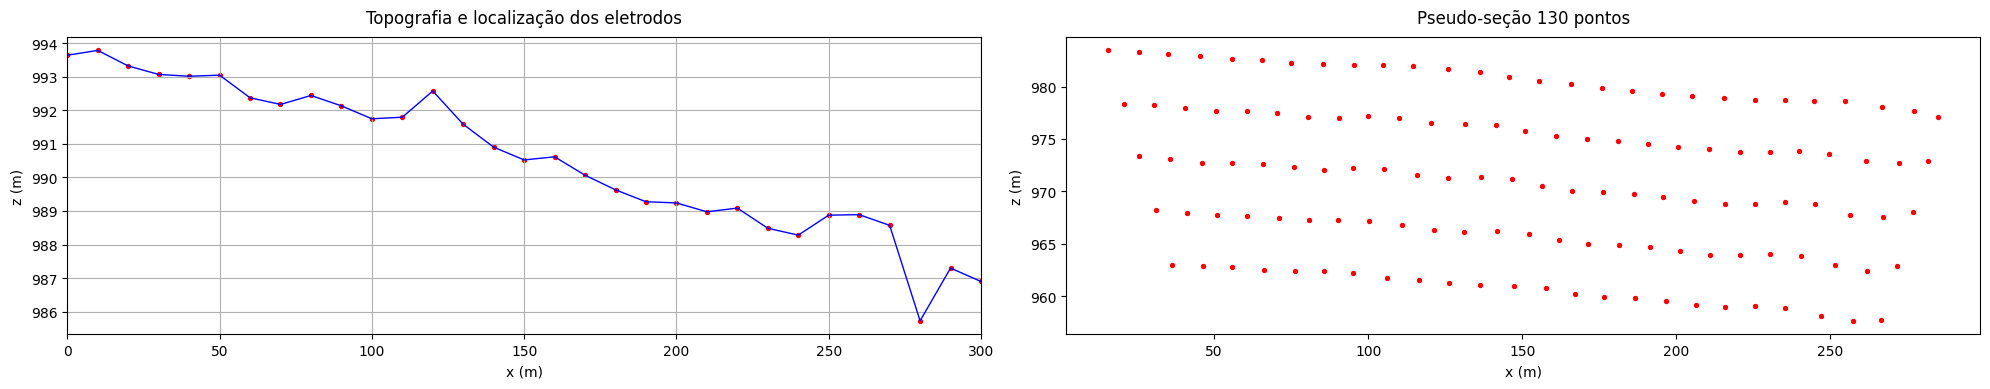

In [ ]:
survey_type = "dipole-dipole"
dimension_type = "2D"
data_type = "volt"
end_locations = np.r_[0, lineLength]

# Generate source list for DC survey line
source_list = generate_dcip_sources_line(
    survey_type,
    data_type,
    dimension_type,
    end_locations,
    topo_2d,
    invLevel,
    eSpace,
)

# Define survey
survey = dc.survey.Survey(source_list, survey_type=survey_type)
pseudo_locations_xz = pseudo_locations(survey)

others = sum(range(1, invLevel))
nElectrodes = int(lineLength / eSpace+1)
nPoints = ((int(lineLength / eSpace + 1)) - (invLevel + 2)) * invLevel + others
closePseudoSection = nPoints - others
print(f'Número de pontos totais : {nPoints}')
print(f'Pontos presentes no "afunilamento" da aquisição: {others}')
print(f'Ponto a partir do qual o trapézio passa a afunilar: {closePseudoSection}')


interp_fun = interp1d(x_topo, z_topo)
electrode_locations_x = np.arange(
    end_locations[0], end_locations[1] + eSpace, eSpace
)
electrode_locations_z = interp_fun(electrode_locations_x)
electrode_locations = np.c_[electrode_locations_x, electrode_locations_z]


fig, axs = plt.subplots(1, 2, figsize=(20, 4))

# Subplot 1
axs[0].plot(x_topo, z_topo, color="b", linewidth=1)
axs[0].scatter(electrode_locations_x, electrode_locations_z, 8, "r")
axs[0].set_xlim([x_topo.min(), x_topo.max()])
axs[0].set_xlabel("x (m)", labelpad=5)
axs[0].set_ylabel("z (m)", labelpad=5)
axs[0].grid(True)
axs[0].set_title("Topografia e localização dos eletrodos", fontsize=12, pad=10)

# Subplot 2
pseudo_locations_xz = pseudo_locations(survey)
axs[1].scatter(pseudo_locations_xz[:, 0], pseudo_locations_xz[:, -1], 8, "r")
axs[1].set_xlabel("x (m)", labelpad=5)
axs[1].set_ylabel("z (m)", labelpad=5)
axs[1].set_title(f"Pseudo-seção {int(nPoints)} pontos", fontsize=12, pad=10)
plt.tight_layout()
plt.show()

## Processando os dados

A função `processAndWriteOutput` é responsável por **processar os dados brutos adquiridos em campo** e gerar um arquivo de saída formatado para softwares de inversão (como **SimPEG**, **ZondRes2D** ou **Res2Dinv**).  

O fluxo de trabalho da função pode ser descrito em três etapas principais:

---

#### 1. Entrada de Dados  
- **Dados de campo (`dataPath`)**: contêm medições de **diferença de potencial (ΔV)** e **corrente injetada (I)**.  
- **Topografia (`topoPath`)**: informações de elevação ao longo da posição dos eletrodos.  
- **Parâmetros do levantamento**: espaçamento entre eletrodos (`eSpace`), número de eletrodos (`nElectrodes`), comprimento da linha (`lineLength`) e nível de investigação (`invLevel`).  
- **Configuração de saída**: formato do arquivo (`outSimpeg`, `outZond`, `outRes2d`) e caminho para salvar o resultado (`fullPath`).  

---

#### 2. Processamento  
A função realiza os seguintes cálculos:  

1. **Cálculo do fator geométrico ($K$)**  
   O fator geométrico depende da disposição dos eletrodos (ABMN). Para um arranjo geral:  

   $$
   K = 2 \pi \left( \frac{1}{AM} - \frac{1}{BM} - \frac{1}{AN} + \frac{1}{BN} \right)^{-1}
   $$  

   onde:  
   - $AM, BM, AN, BN$ = distâncias entre os eletrodos de corrente (A, B) e de potencial (M, N).  

2. **Cálculo da resistividade aparente ($\rho_a$)**  
   A resistividade aparente é então obtida por:  

   $$
   \rho_a = K \cdot \frac{\Delta V}{I}
   $$  

   Esse valor representa a resistividade "efetiva" do subsolo para a configuração eletrodo utilizada.

---

#### 3. Geração do Arquivo de Saída  
Após o cálculo, a função organiza os resultados em um **arquivo de saída** compatível com o software de inversão selecionado:  

- **SimPEG** → formato `.txt` estruturado para uso direto no framework.  
- **ZondRes2D** → formato `.txt`estruturado para uso direto no Zond®.  
- **Res2Dinv** → formato `.dat` padrão para inversão no Res2Dinv®.  

O arquivo contém:  
- Geometria da linha de aquisição;  
- Dados de topografia;  
- Resistividade aparente calculada para cada arranjo de eletrodos.  

---

> **Em resumo:** a função automatiza todo o fluxo de trabalho desde o dado bruto de campo até a geração de arquivos prontos para inversão, garantindo padronização, reprodutibilidade e compatibilidade com múltiplos softwares.



In [ ]:
def dataProcessing(realTopography, dataPath, topoPath, fullPath, normalTxt, gtestTxt, outSimpeg, outZond, outRes2d):


    with open(dataPath, 'r', encoding='latin-1') as file:
        linhas = file.readlines()
    # Ignora linhas que começam com '#'
    linha = [linha.strip() for linha in linhas if not linha.startswith('#') and not linha.strip().startswith('FIM')]


########################################### .txt normal ############################################


    if normalTxt:

      lineLength = int(linha[0].split('#')[0].strip())
      eSpace = int(linha[1].split('#')[0].strip())
      invLevel = int(linha[2].split('#')[0].strip())

      volt = []
      amper = []
      index = []

      for linha in linha[3:]:
          column = linha.split()
          indice = int(column[0])

          media_volt = np.mean([float(column[1]),float(column[3]),float(column[5])])
          media_amper = np.mean([float(column[2]),float(column[4]),float(column[6])])

          #v1 = float(column[1])
          #v2 = float(column[3])
          #v3 = float(column[5])

          #i1 = float(column[2])
          #i2 = float(column[4])
          #i3 = float(column[6])

          index.append(indice)
          #volt.append([v1, v2, v3])
          volt.append(media_volt)
          amper.append(media_amper)
          #amper.append([i1, i2, i3])


      res = [v / i for v, i in zip(volt, amper)]              # Resistência
      nElectrodes = int(lineLength / eSpace) + 1


############################################ .txt gtest ############################################


    if gtestTxt:

      data = []
      volt = []
      Mamper = []
      res = []
      rhoa = []
      rhoa2d = []
      points = []
      index = []

      invLevel = int(linha[4])
      nElectrodes = int(linha[5])
      eSpace = int(float(linha[6].replace(",", ".")))
      lineLength = (nElectrodes - 1) * eSpace

      inicio = None
      for i, l in enumerate(linha):
        colunas = l.split()
        if len(colunas) >= 8:
            if colunas[0].isdigit() and colunas[1].isdigit():
                inicio_dados = i
                break

      linha = linha[inicio_dados:]

      for linha_dado in linha[:]:
        # Ignora linhas que começam com FIM
          if linha_dado.strip().upper().startswith("FIM"):
            continue

          column = linha_dado.split()

          indice = int(column[0])
          point = float(column[1])
          v = float(column[2])
          i = float(column[3])
          r = float(column[4])

          data.append([v, v, v])
          index.append(indice)
          points.append(point)
          volt.append(v)
          Mamper.append(i)
          rhoa.append(r)
          rhoa2d.append(r)
          res.append(v / i if i != 0 else 0)



      dados_ordenados = sorted(zip(points, volt, Mamper, rhoa, res), key=lambda x: x[0])
      points, volt, Mamper, rhoa, res = zip(*dados_ordenados)

      points = list(points)
      volt = list(volt)
      Mamper = list(Mamper)
      rhoa = list(rhoa)
      res = list(res)
      index = list(index)

      orderedData = np.array([], dtype=float)


####################################### Survey e Topografia ########################################


    others = sum(range(1, invLevel))

    nPoints = ((int(lineLength / eSpace + 1)) - (invLevel + 2)) * invLevel + others
    closePseudoSection = nPoints - others

    Ax = 0
    Bx = eSpace
    Mx = Bx + eSpace
    Nx = Mx + eSpace

    topography = {}

# Topografia

    if realTopography:
        topo = np.loadtxt(topoPath)
        x_topo = topo[:, 0]
        z_topo = topo[:, 1]
        # Cria dicionário topography associando x a z
        topography = dict(zip(x_topo, z_topo))
        # topo_2d já está no formato correto
        topo_2d = np.c_[x_topo, z_topo]

        if outSimpeg:
            topo_Ax = topography.get(Ax, 0)
            topo_Bx = topography.get(Bx, 0)
            topo_Mx = topography.get(Mx, 0)
            topo_Nx = topography.get(Nx, 0)


    else:
        x_topo = np.arange(0, lineLength + eSpace, eSpace)
        z_topo = np.zeros_like(x_topo)
        topo_Ax = topo_Bx = topo_Mx = topo_Nx = 0
        topo_2d = np.c_[x_topo, z_topo]

# Survey

    survey_type = "dipole-dipole"
    dimension_type = "2D"
    data_type = "volt"
    end_locations = np.r_[0, lineLength]

    source_list = generate_dcip_sources_line(
        survey_type,
        data_type,
        dimension_type,
        end_locations,
        topo_2d,
        invLevel,
        eSpace,)


    survey = dc.survey.Survey(source_list, survey_type=survey_type)
    pseudo_locations_xz = pseudo_locations(survey)

#################################### Calculando Res. Aparente ######################################


    if normalTxt:
      k = np.zeros(invLevel)
      rhoa = np.zeros(len(volt))
      rhoa2d = np.zeros(len(rhoa))

      for n in range(1, invLevel + 1):
          # Fator Geométrico
          G = 1 / ((1/n) - (2/(n+1)) + (1/(n+2)))
          k[n - 1] = 2.0 * np.pi * G * eSpace


      for i in range(len(volt)):
          # Resistividade Aparente
          rhoa[i] = np.abs(k[min(int(index[i]-1), len(k)-1)] * (volt[i] / amper[i]))


      topo_2d = np.c_[x_topo[:len(rhoa)], z_topo[:len(rhoa)]]
      orderedData = np.array([], dtype=float)
      rhoa2d = rhoa
      print(rhoa2d)


#Escrita
    with open(fullPath, 'w') as f:
######################################### Escrita - SimPEG #########################################


        if outSimpeg:
            f.write(f'0 {topo_Ax} {eSpace} {topo_Bx} {invLevel}\n')
            i = 0

            while i < len(data):
                for j in range(min(invLevel, len(data) - i)):
                    f.write(f'{Mx} {topo_Mx} {Nx} {topo_Nx} {volt[i]}\n')
                    Mx += eSpace
                    Nx += eSpace
                    i += 1

                Ax += eSpace
                Bx += eSpace
                Mx = Bx + eSpace
                Nx = Mx + eSpace

                if i >= closePseudoSection and invLevel > 1:
                    invLevel -= 1

                if i == len(data):
                    invLevel -= 1
                    break

                f.write(f'{Ax} {topo_Ax} {Bx} {topo_Bx} {invLevel}\n')


######################################### Escrita - Res2D ##########################################


        if outRes2d:

            displPointsPosition = np.array([])
            for i in range(invLevel):

                displInc = 3*eSpace/2 + i*eSpace/2
                levelPoints = np.arange(displInc,lineLength - displInc + 1,eSpace)
                displPointsPosition = np.append(displPointsPosition,levelPoints)

            f.write(fileName+"\n")                                                                  # Linha do título
            f.write(str(eSpace)+"\n")                                                               # Espaçamento do eletrodo
            f.write("3\n")                                                                          # 3 indica o tipo de levantamento (dipolo-dipolo)
            f.write(str(nPoints)+"\n")                                                              # Número de ponto do levantamento
            f.write("0\n")                                                                          # 0 indica espaçamento unitário, sem 'skips'
            f.write("0\n")                                                                          # 0 indica que não há dados de IP

            for levels in range(invLevel):
                cont = 0

                for k, n in enumerate(index):
                    if (n == levels+1):
                        x = topo_2d[cont,0]
                        r = rhoa2d[k]
                        f.write(f"{x:.1f}, {eSpace:.1f}, {levels+1}, {r:.1f}\n")                    # Escreve posição x do primeiro eletrodo , espaçamento , subnível , rhoa
                        orderedData = np.append(orderedData, float(r))
                        cont += 1

            if realTopography:

                f.write("2\n")
                f.write(f"{nElectrodes}\n")

                for i in range(len(topo_2d)):

                    f.write(f"{topo_2d[i,0]} , {topo_2d[i,1]}\n")

                f.write("0\n0\n0\n0\n")
                f.close()

            if not realTopography:
                f.write("0\n0\n0\n0\n")
                f.close()


######################################### Escrita - Zond ###########################################


        if outZond:
            f.write("C1\tC2\tP1\tP2\tro_a\tres\tweight\n")
            i = 0

            while i < len(data) and i < len(rhoa):
                for j in range(min(invLevel, len(rhoa) - i)):
                    f.write(f'{Ax}\t{Bx}\t{Mx}\t{Nx}\t{rhoa[i]:.8f}\t{res[i]:.8f}\t{1}\n')
                    Mx += eSpace
                    Nx += eSpace
                    i += 1

                Ax += eSpace
                Bx += eSpace
                Mx = Bx + eSpace
                Nx = Mx + eSpace

                if i >= closePseudoSection and invLevel > 1:
                    invLevel -= 1

                if i == len(data):
                    invLevel -=1
                    break


####################################################################################################


    # Acha o menor valor positivo real
    rhoa_arr = np.array(rhoa, dtype=float)
    min_pos = np.min(rhoa_arr[rhoa_arr > 0])
    # Substitui valores <= 0 por uma fração desse mínimo
    rhoa_arr[rhoa_arr <= 0] = min_pos * 0.1


    # Plot pseudo-seção de resistividade aparente
    fig, ax = plt.subplots(figsize=(15, 5))
    plot_pseudosection(
        survey,
        rhoa_arr,
        plot_type="contourf",
        ax=ax,
        scale="log",
        cbar_label="$\Omega m$",
        mask_topography=True,
        contourf_opts={"levels": 20, "cmap": mpl.cm.jet},)
    ax.set_title("Resistividade aparente")
    ax.set_xlabel("x (m)")
    ax.set_ylabel("z (m)")
    plt.tight_layout()
    plt.show()

    return volt, rhoa_arr

<>:326: SyntaxWarning: invalid escape sequence '\O'
<>:326: SyntaxWarning: invalid escape sequence '\O'
/tmp/ipykernel_1881/3437443582.py:326: SyntaxWarning: invalid escape sequence '\O'
  cbar_label="$\Omega m$",


/usr/local/lib/python3.12/dist-packages/simpeg/electromagnetics/static/resistivity/survey.py:31: FutureWarning: Argument 'survey_type' is ignored and will be removed in future versions of SimPEG. Types of sources and their corresponding receivers are obtained from their respective classes, without the need to specify the survey type.
  warnings.warn(


[1.07442917e+02 5.25811612e+02 1.73513182e+03 1.05447562e+03
 4.73761509e+03 3.56312281e+02 1.26996294e+03 1.64390538e+02
 3.56245787e+03 1.67109209e+04 4.87538957e+02 3.89060514e+02
 2.28688040e+03 3.05091561e+04 9.14604464e+03 1.92140148e+01
 6.10514269e+02 4.60317482e+03 3.23071161e+03 7.49893396e+03
 1.27854234e+02 5.06962735e+02 1.17860684e+03 2.86390268e+03
 3.26550465e+03 8.41152290e+01 4.65528380e+02 1.58942860e+03
 2.01970276e+03 1.75105519e+03 2.11522898e+02 1.00013241e+03
 1.45141735e+03 7.80332821e+02 3.84403257e+03 1.73426045e+02
 4.07234086e+02 2.00044149e+03 5.21959327e+03 2.89057988e+03
 1.20147754e+02 2.01525051e+02 3.09758928e+02 1.66427712e+03
 6.53088780e+02 4.02441211e+01 6.63063551e+02 9.80940969e+02
 2.88560201e+02 6.39708475e+02 1.70675789e+02 4.00696382e+02
 1.13268818e+02 4.27664625e+02 5.06711781e+03 1.13040876e+02
 3.47297207e+00 2.18856754e+02 2.72714856e+03 3.89006772e+04
 1.27100946e+01 1.45787474e+02 1.12456293e+03 1.55861961e+04
 3.60588043e+03 2.365601

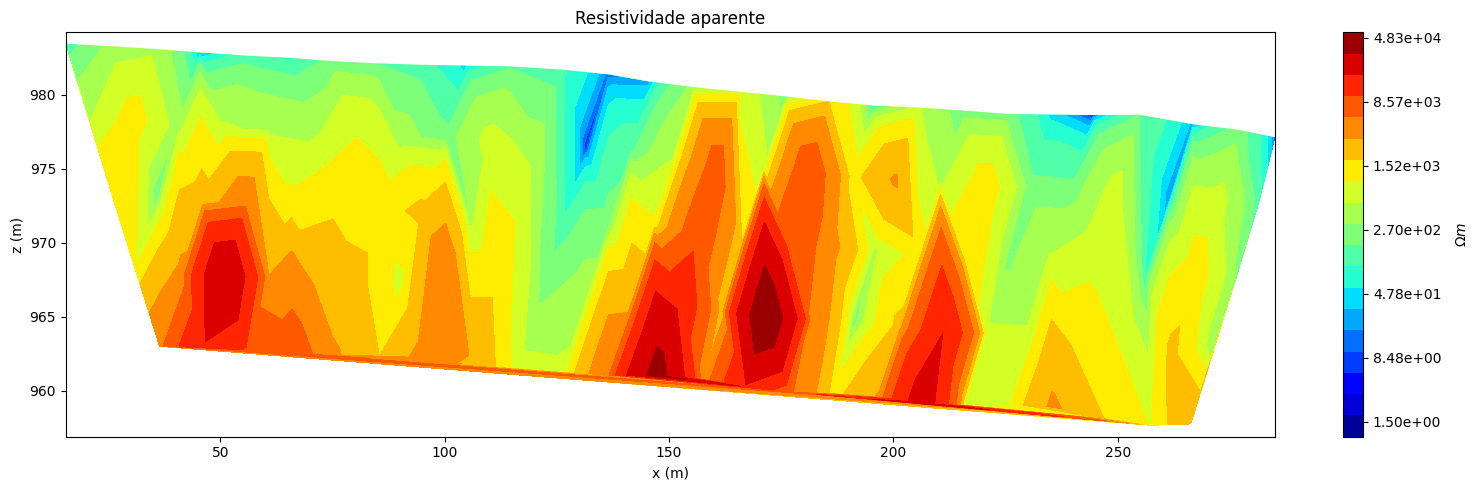

In [ ]:
volt, rhoa_arr = dataProcessing(realTopography, dataPath, topoPath, fullPath, normalTxt, gtestTxt, outSimpeg, outZond, outRes2d)